# Subtiles Puzzle Walkthrough

This notebook goes from the given clues to the final numeric answer.
Note that this is an abridged (and frankly cleaner) version  of my actual solution

In [37]:
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import Image, display

from Feb2026.solver import (
    Puzzle,
    SubtilesNotebookSolver,
    build_fixed_values,
    discover_forced_subset,
    render_solution,
)


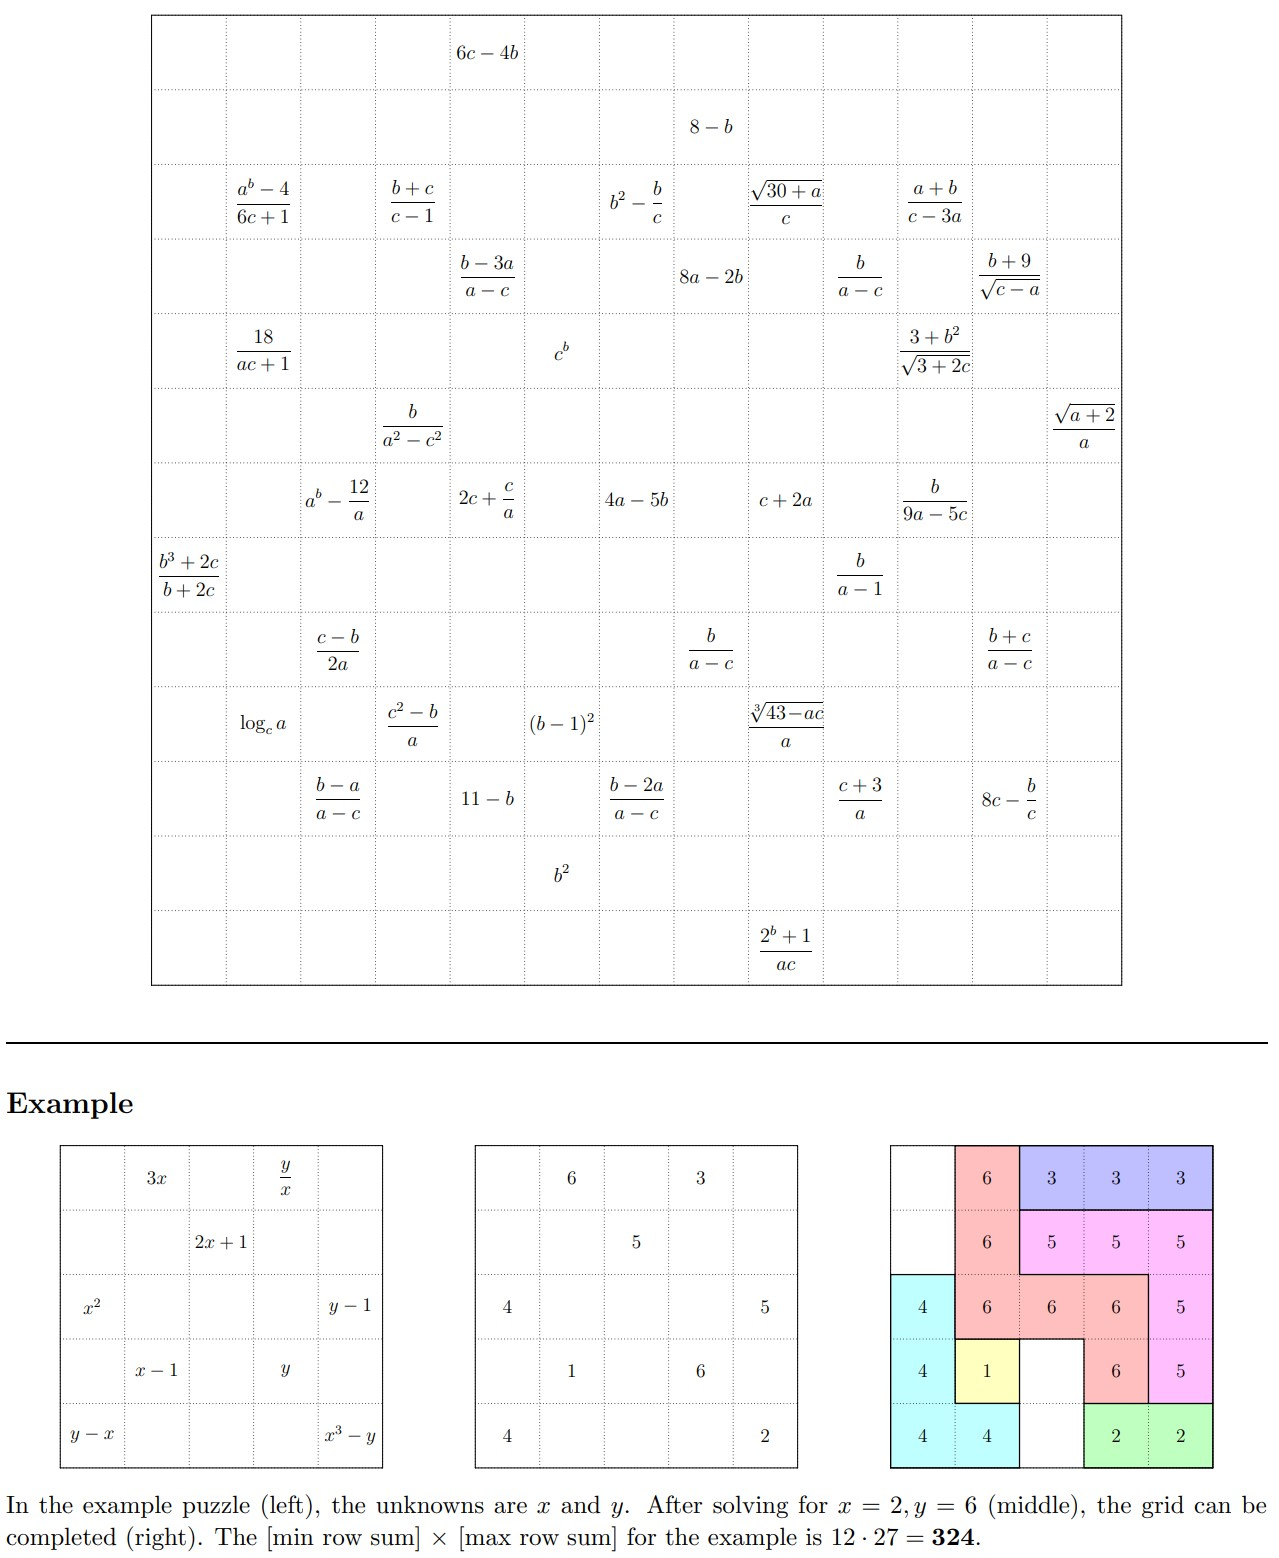

In [38]:
display(Image(filename="image.png"))

# Let: a = 1/4, b = -3, and c = 1/2

In [39]:
CLUES = np.array([
    [0, 0, 0, 0, 15, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 11, 0, 0, 0, 0, 0],
    [0, 15, 0, 5, 0, 0, 15, 0, 11, 0, 11, 0, 0],
    [0, 0, 0, 0, 15, 0, 0, 8, 0, 12, 0, 12, 0],
    [0, 16, 0, 0, 0, 8, 0, 0, 0, 0, 6, 0, 0],
    [0, 0, 0, 16, 0, 0, 0, 0, 0, 0, 0, 0, 6],
    [0, 0, 16, 0, 3, 0, 16, 0, 1, 0, 12, 0, 0],
    [13, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0],
    [0, 0, 7, 0, 0, 0, 0, 12, 0, 0, 0, 10, 0],
    [0, 2, 0, 13, 0, 16, 0, 0, 14, 0, 0, 0, 0],
    [0, 0, 13, 0, 14, 0, 14, 0, 0, 14, 0, 10, 0],
    [0, 0, 0, 0, 0, 9, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 9, 0, 0, 0, 0],
], dtype=int)

# Candidate high value deductions to prune automatically.
# The notebook will shrink this set to the discovered forced scaffold.
FORCED_CANDIDATES = [
    (3, 10, 12), (4, 9, 12), (5, 9, 12), (7, 10, 12), (8, 8, 12), (8, 9, 12), (8, 10, 12),
    (7, 1, 13), (7, 2, 13), (7, 3, 13), (8, 3, 13), (11, 2, 13), (12, 2, 13), (12, 3, 13),
    (12, 4, 13), (8, 4, 14), (9, 4, 14), (9, 7, 14), (9, 9, 14), (10, 5, 14), (11, 9, 14),
    (1, 5, 15), (2, 0, 15), (2, 2, 15), (2, 5, 15), (3, 0, 15), (3, 2, 15), (3, 3, 15),
    (3, 5, 15), (4, 0, 15), (5, 1, 16), (5, 4, 16), (5, 5, 16), (5, 6, 16), (6, 1, 16),
    (6, 3, 16), (6, 7, 16), (7, 6, 16), (8, 5, 16),
]

N = 16
ROWS, COLS = CLUES.shape
GIVEN_CELLS = {(r, c) for r in range(ROWS) for c in range(COLS) if CLUES[r, c] > 0}


In [40]:
def draw_grid(ax, grid, title, given_cells=None, forced_cells=None):
    ax.imshow(grid, cmap="tab20_r", vmin=0, vmax=N)

    for r in range(grid.shape[0]):
        for c in range(grid.shape[1]):
            value = int(grid[r, c])
            ax.text(c, r, "" if value == 0 else str(value), ha="center", va="center", fontsize=8)

    ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
    ax.grid(which="minor", color="black", linewidth=0.7)

    if given_cells:
        for r, c in given_cells:
            ax.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="black", lw=2.0))

    if forced_cells:
        for r, c in forced_cells:
            ax.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="#ff8c00", lw=2.0))

    ax.set_title(title, fontsize=12)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)


def print_grid_text(grid, title):
    print(f"\n{title} (text view):")
    for row in grid:
        print(" ".join(f"{int(v):2d}" for v in row))


def grid_with_forced(forced):
    grid = CLUES.copy()
    cells = set()
    for r, c, value in forced:
        grid[r, c] = value
        cells.add((r, c))
    return grid, cells


## Constraint Model

The solver enforces all puzzle rules directly:
- value `k` appears exactly `k` times
- each set of `k` cells is orthogonally connected
- each `k`-omino must contain the `(k-1)` shape up to rotation/reflection

The code then uses DFS with pruning/caching to keep search practical.


# Solver internals (types, transforms, DFS, pruning) are imported from solver.py

## Forced-Cell Discovery

Before running the full search, we identify a small scaffold of cells that are effectively forced.

Method:
1. Start from a high-value candidate pool (12 to 16), where placements are most constrained.
2. Remove one candidate at a time.
3. Keep a candidate only when removing it breaks the targeted solve budget.

Result:
- `AUTO_FORCED` is the reduced scaffold used in the final solve.
- This keeps the walkthrough fast while preserving the correct final grid.


In [41]:
AUTO_FORCED, AUTO_REMOVED = discover_forced_subset(
    CLUES,
    FORCED_CANDIDATES,
    N,
    max_nodes=3000,
    timeout_s=0.6,
)

print(f"candidate count: {len(FORCED_CANDIDATES)}")
print(f"removed by pruning: {len(AUTO_REMOVED)}")
print(f"discovered forced count: {len(AUTO_FORCED)}")


candidate count: 39
removed by pruning: 18
discovered forced count: 21


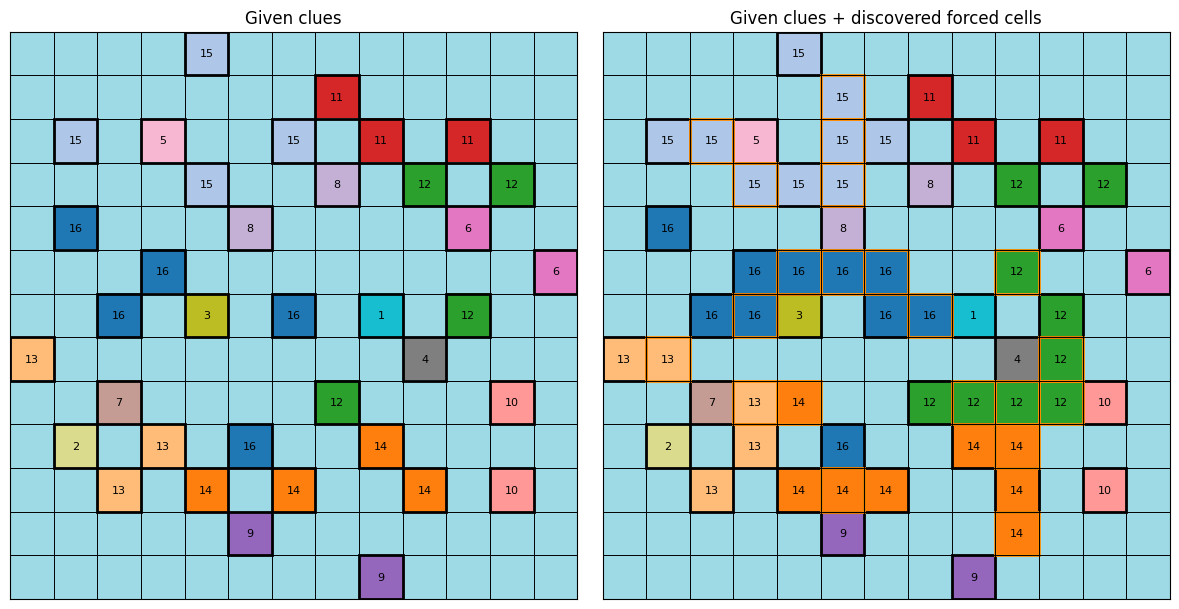

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

draw_grid(axes[0], CLUES, "Given clues", given_cells=GIVEN_CELLS)

auto_grid, auto_cells = grid_with_forced(AUTO_FORCED)
draw_grid(
    axes[1],
    auto_grid,
    "Given clues + discovered forced cells",
    given_cells=GIVEN_CELLS,
    forced_cells=auto_cells,
)

plt.tight_layout()
plt.show()


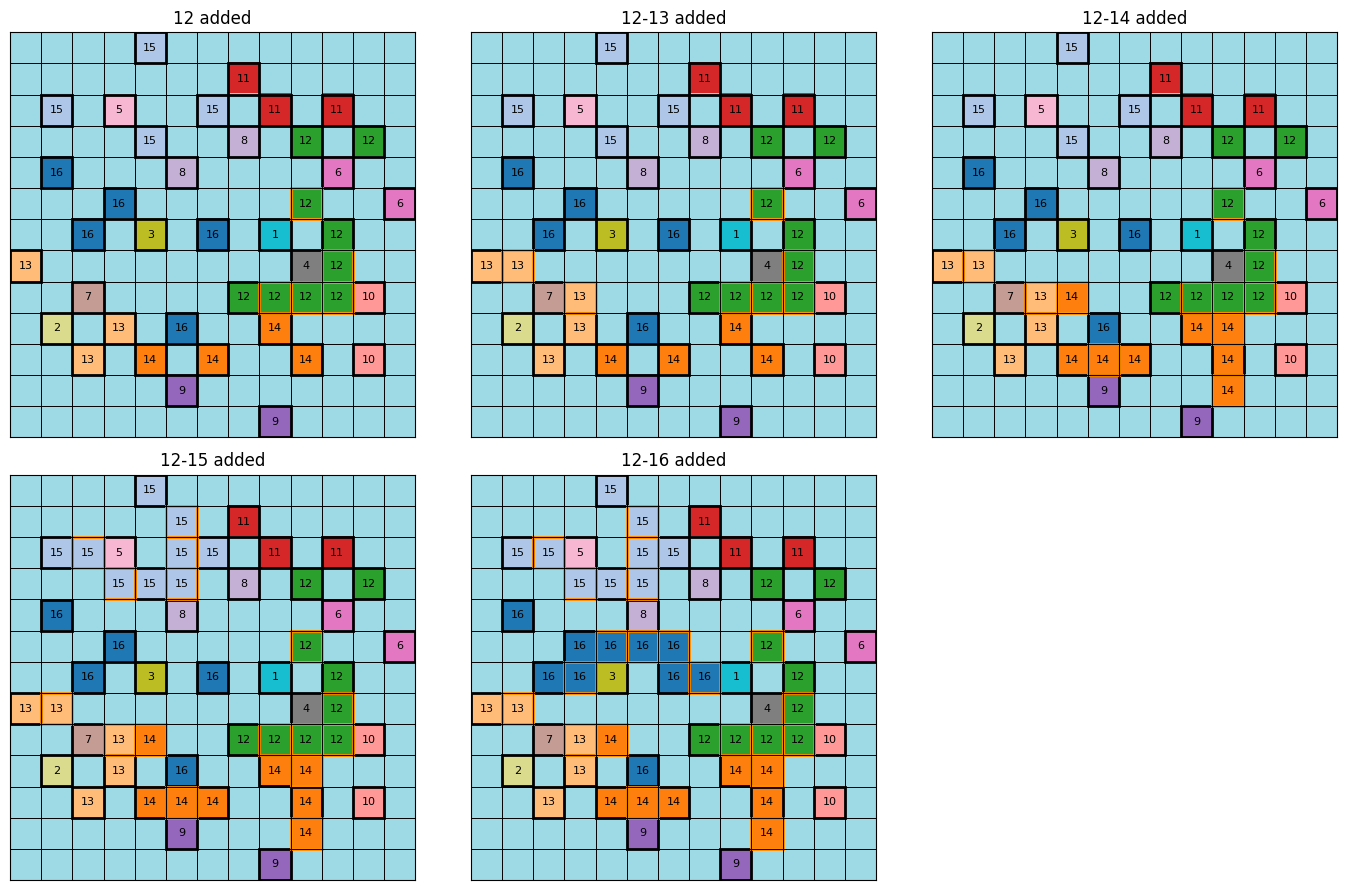

Discovered forced cells by value:
12: 5
13: 2
14: 4
15: 5
16: 5


In [43]:
# Progression view by value, using discovered forced cells
steps = [
    ("12 added", {12}),
    ("12-13 added", {12, 13}),
    ("12-14 added", {12, 13, 14}),
    ("12-15 added", {12, 13, 14, 15}),
    ("12-16 added", {12, 13, 14, 15, 16}),
]

# 3 on top row, 2 on bottom row (last slot intentionally blank)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes_flat = axes.ravel()

for i, (title, values) in enumerate(steps):
    ax = axes_flat[i]
    subset = [entry for entry in AUTO_FORCED if entry[2] in values]
    step_grid, step_cells = grid_with_forced(subset)
    draw_grid(ax, step_grid, title, given_cells=GIVEN_CELLS, forced_cells=step_cells)

# Hide unused 6th panel
axes_flat[-1].axis("off")

plt.tight_layout()
plt.show()

forced_by_value = defaultdict(list)
for r, c, value in AUTO_FORCED:
    forced_by_value[value].append((r, c))

print("Discovered forced cells by value:")
for value in sorted(forced_by_value):
    print(f"{value}: {len(forced_by_value[value])}")


## Final Solve

Now we solve using the discovered scaffold (`AUTO_FORCED`), render the completed grid, and verify counts before computing row sums.


Final solve stats: nodes=2997, seconds=0.398


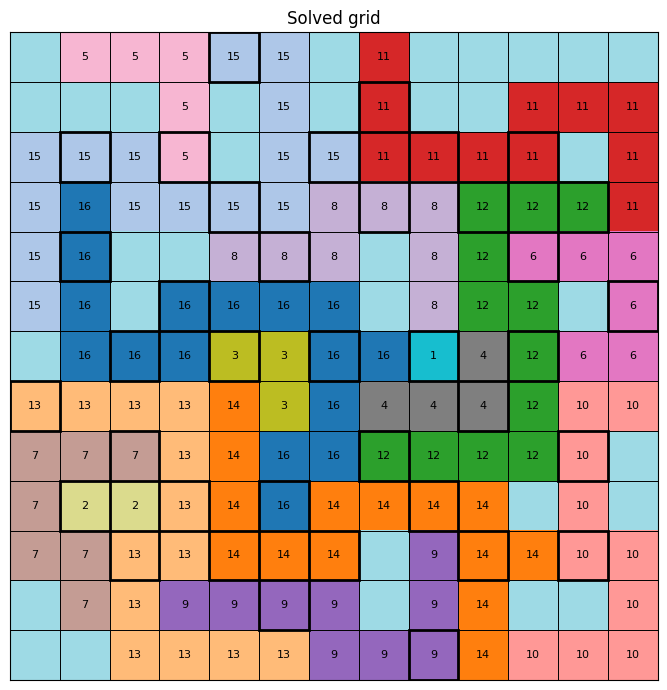

In [44]:
solver = SubtilesNotebookSolver(Puzzle(ROWS, COLS, build_fixed_values(CLUES, AUTO_FORCED)))
placed = solver.solve(N)
solved_grid = np.array(render_solution(ROWS, COLS, placed), dtype=int)

print(f"Final solve stats: nodes={solver.stats['nodes']}, seconds={solver.stats['seconds']:.3f}")

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
draw_grid(ax, solved_grid, "Solved grid", given_cells=GIVEN_CELLS)
plt.tight_layout()
plt.show()


In [45]:
# Validate counts and compute final answer
counts = Counter(solved_grid.ravel())
for k in range(1, N + 1):
    assert counts[k] == k, f"Count mismatch for {k}: expected {k}, got {counts[k]}"

row_sums = solved_grid.sum(axis=1).tolist()
min_sum = min(row_sums)
max_sum = max(row_sums)
answer = min_sum * max_sum

print("Row sums:", row_sums)
print(f"min row sum = {min_sum}")
print(f"max row sum = {max_sum}")
print(f"final answer = {min_sum} * {max_sum} = {answer}")


Row sums: [56, 64, 135, 162, 93, 133, 115, 129, 138, 120, 139, 89, 123]
min row sum = 56
max row sum = 162
final answer = 56 * 162 = 9072


## Final Result

From the solved grid:
- minimum row sum = `56`
- maximum row sum = `162`

Puzzle answer:

**56 × 162 = 9072**
